In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

def run_test(true_lift, test_weeks, rng, n_test=5, n_markets=20, pre_days=90):
    baseline = rng.integers(50, 500, size=n_markets)
    is_test = np.zeros(n_markets, dtype=bool)
    is_test[rng.choice(n_markets, size=n_test, replace=False)] = True

    n_days = pre_days + test_weeks * 7
    day = np.arange(n_days)
    weekly = np.where(day % 7 >= 5, 0.85, 1.0)
    slope = rng.normal(0.0005, 0.0003, size=(n_markets, 1))
    trend = 1 + slope * day
    noise = rng.normal(1.0, 0.08, size=(n_markets, n_days))

    regs = baseline[:, None] * weekly * trend * noise
    regs[is_test, pre_days:] *= 1 + true_lift

    log_regs = np.log(regs)
    change = log_regs[:, pre_days:].mean(axis=1) - log_regs[:, :pre_days].mean(axis=1)
    est = np.exp(change[is_test].mean() - change[~is_test].mean()) - 1
    p = stats.ttest_ind(change[is_test], change[~is_test]).pvalue
    return est, p

In [2]:
rng = np.random.default_rng(42)
est, p = run_test(true_lift=0.15, test_weeks=4, rng=rng)
print(f"Estimated lift: {est:.1%}, p-value: {p:.4f}")

Estimated lift: 16.5%, p-value: 0.0000


In [3]:
rng = np.random.default_rng(42)
rows = []
for weeks in [2, 4, 8]:
    for lift in [0, 0.01, 0.02, 0.03, 0.04, 0.06]:
        pvals = np.array([run_test(lift, weeks, rng)[1] for _ in range(500)])
        rows.append({"weeks": weeks, "true_lift": lift, "power": (pvals < 0.05).mean()})

power = pd.DataFrame(rows)
power_table = power.pivot(index="true_lift", columns="weeks", values="power")
power_table

weeks,2,4,8
true_lift,,,
0.00,0.050,0.064,0.040
0.01,0.088,0.112,0.134
0.02,0.270,0.332,0.326
0.03,0.492,0.592,0.588
0.04,0.772,0.856,0.836
0.06,0.976,0.996,0.996


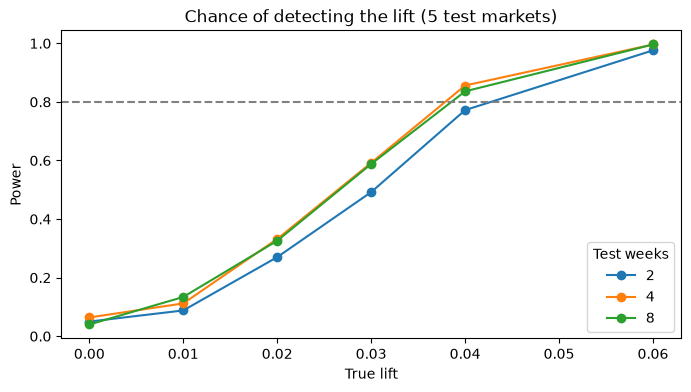

In [6]:
ax = power_table.plot(marker="o", figsize=(8, 4),
                      title="Chance of detecting the lift (5 test markets)")
ax.axhline(0.8, color="gray", linestyle="--")
ax.set_xlabel("True lift")
ax.set_ylabel("Power")
ax.legend(title="Test weeks")
plt.savefig("../images/power_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
rng = np.random.default_rng(42)
rows = []
for n_test in [5, 10]:
    for lift in [0, 0.01, 0.02, 0.03, 0.04, 0.06]:
        pvals = np.array([run_test(lift, 4, rng, n_test=n_test)[1] for _ in range(500)])
        rows.append({"n_test": n_test, "true_lift": lift, "power": (pvals < 0.05).mean()})

pd.DataFrame(rows).pivot(index="true_lift", columns="n_test", values="power")

n_test,5,10
true_lift,,
0.00,0.060,0.044
0.01,0.128,0.130
0.02,0.316,0.412
0.03,0.628,0.746
0.04,0.854,0.936
0.06,0.988,1.000
